# Adversarial Image Captioning Attack

The exploration of adversarial robustness in vision-language models has its roots in the work of Shekhar et al. (2017), who were among the first to test whether deep models for vision and language truly capture the interaction between the two modalities. Their study can be seen as an early stress test for multimodal understanding, questioning whether these models genuinely reason about images and text or simply exploit dataset regularities.

Following this, Chen et al. (2018) introduced *Show-and-Fool*, which extended the idea of adversarial attacks to image captioning models. At that time, most research focused on CNN-based image classifiers, where adversarial examples were already known to cause misclassifications through imperceptible pixel perturbations. However, captioning models pose a more complex challenge, because instead of predicting a single class label, they generate natural language sentences, and semantically similar captions can be phrased in many different ways. Simply treating each caption as a distinct class would result in an enormous output space, exceeding the number of training examples. Moreover, recurrent architectures such as RNNs had been less explored in adversarial contexts. Show-and-Fool addressed these challenges by formulating caption manipulation as an optimization problem over the input image, targeting either full sentences or specific keywords. Their results demonstrated that standard CNN-RNN captioning models could be fooled with visually imperceptible perturbations, revealing limited robustness against adversarial attacks.

Building on this line of work, Xu et al. (2019) proposed the *GEM* attack (Generalized Expectation Maximization), which reframed adversarial image captioning as a structured output learning problem with latent variables. By jointly optimizing over input perturbations and hidden word sequences using a max-margin objective, GEM achieved more controlled manipulations of the generated captions while keeping the perturbations imperceptible.

More recently, Li et al. (2024) introduced *AICAttack*, an adversarial image captioning attack that uses attention-based optimization. Their approach operates in a black-box setting, selecting candidate pixels for perturbation based on attention maps from the underlying captioning model. The idea is to subtly distort the generated captions while leaving the image visually unchanged. Li et al. use previous attacks such as Show-and-Fool and GEM as baselines and evaluate their method on attention-based captioning architectures like Show-Attend-and-Tell (Xu et al., 2016) and BLIP (Li et al., 2022).

In this project, we aim to extend this line of research to more recent model architectures. All previous works were conducted on CNN-RNN based captioning models, which are no longer the state of the art. We therefore investigate whether the AICAttack principle can be applied to Vision Transformer–based architectures, more particular the ViT-GPT2 image captioning model (Srija et al., 2025). By doing so, we explore whether we can apply AICAttack to fool modern encoder-decoder models that combine transformer-based vision and language components.

### Placeholder AIC Attack - SAT description & how this works

TextTextText

### Import Libraries, Set Seeds, and Select GPU

In [1]:
#Importing libraries
import json
import os
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, ViTImageProcessor, VisionEncoderDecoderModel
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

/Users/katinkakurz/Desktop/NLP Final/Advanced-Machine-Learning-for-Natural-Language-Processing/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# GPU setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


### Load COCO Mini Dataset & Displaying Sample Image

COCO is a large-scale object detection, segmentation and captioning dataset with 330k images. Each of the images in the COCO dataset is accompanied by five human-generated captions and spans across 80 object categories. Lin et al. (2014) also tested their AIC Attack  on the COCO dataset, allowing for comparable results.

Loading the entire original dataset requires significant memory requirements. As the purpose of this project is to simply test the effectiveness of an AIC Attack on a transformer-based image captioning model, we chose a smaller subset of the COCO dataset with less memory requirements: the Mini COCO2014 Dataset contains 18.7k images, each with 5 original subcaptions. The dataset can be found on kaggle: https://www.kaggle.com/datasets/nagasai524/mini-coco2014-dataset-for-image-captioning

In [4]:
# Download dataset
data_path = kagglehub.dataset_download(
    "nagasai524/mini-coco2014-dataset-for-image-captioning")

In [5]:
#Function to load all human annotated captions by image
def load_captions(dataset_path):
    """Load image_id -> list of captions mapping from captions.json."""
    captions_path = os.path.join(dataset_path, "captions.json")
    with open(captions_path, "r") as f:
        data = json.load(f)
    annotations = data["annotations"] if isinstance(data, dict) else data
    captions = {}
    for ann in annotations:
        img_id = ann["image_id"]
        captions.setdefault(img_id, []).append(ann["caption"])
    return captions

In [6]:
def find_image_folder(dataset_path, ext=".jpg"):
    """Find first folder under dataset_path that contains image files."""
    for root, _, files in os.walk(dataset_path):
        if any(f.lower().endswith(ext) for f in files):
            return root
    raise RuntimeError(f"No image folder with *{ext} found under {dataset_path}")

In [7]:
#Loading images and captions
captions = load_captions(data_path)
img_folder = find_image_folder(data_path)
img_ids = sorted(captions.keys())
print(f"Dataset loaded, {len(img_ids)} images with captions")

Dataset loaded, 18783 images with captions


In [8]:
def get_image(idx):
    """Load image and its captions by index in img_ids."""
    img_id = img_ids[idx]
    candidates = [
        os.path.join(img_folder, f"COCO_train2014_{img_id:012d}.jpg"),
        os.path.join(img_folder, f"{img_id}.jpg"),
    ]
    for img_path in candidates:
        if os.path.exists(img_path):
            img = Image.open(img_path).convert("RGB")
            return img, captions[img_id]
    raise FileNotFoundError(f"No image file found for image_id {img_id}")


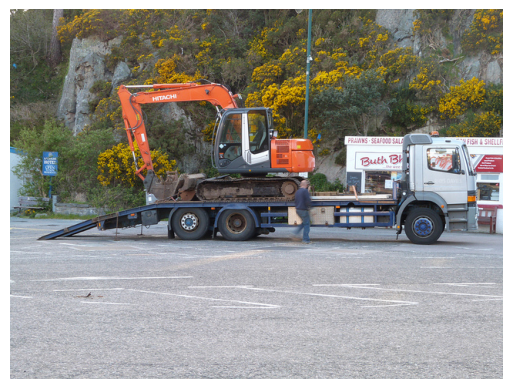

Image index: 6016, image_id: 190845
Ground truth captions:
  - A large transport truck with an orange tractor on back of it.
  - An orange backhoe atop the bed of a white truck.
  - a man loading a bulldozer onto a car hauler 
  - A large truck parked in a stationary position.
  - A tow truck carrying a bulldozer on a trailer.


In [9]:
# Visual inspection of sample image
idx = 6016
img, caps = get_image(idx)
plt.imshow(img)
plt.axis("off")
plt.show()
print(f"Image index: {idx}, image_id: {img_ids[idx]}")
print("Ground truth captions:")
for cap in caps:
    print(f"  - {cap}")

### Load ViT-GPT2 & Attention Investigation

The ViT-GPT2 model description XXX

In [26]:
#Loading pre-trained transformer model for image captioning
model_name = "nlpconnect/vit-gpt2-image-captioning"

model = VisionEncoderDecoderModel.from_pretrained(
    model_name,
    attn_implementation="eager").to(device)

feature_extractor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

model.eval()

print(f"Loaded model: {model_name}")
#Attention implementation set to eager to ensure cross-attention weights are available
print(f"Decoder attention implementation: {model.config.decoder._attn_implementation}")

'(ProtocolError('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer')), '(Request ID: 7a601c10-8371-430a-939d-fcace58a7a9f)')' thrown while requesting HEAD https://huggingface.co/nlpconnect/vit-gpt2-image-captioning/resolve/main/config.json
Retrying in 1s [Retry 1/5].


Loaded model: nlpconnect/vit-gpt2-image-captioning
Decoder attention implementation: eager


In [27]:
@torch.no_grad() #ensure no gradients are computed
def generate_caption_and_attention(img, max_length=16):
    """
    Generate a caption for a PIL image and return:
    - caption (str)
    - cross_attentions (list of tensors)
    - encoder_hidden_states (tensor)
    """
    #Image -> pixel_values: 
    pixel_values = feature_extractor(images=img, return_tensors="pt").pixel_values.to(device)
    print(f"pixel_values.shape: {pixel_values.shape}")
    # Encode image; print for improved understanding of dimensionality
    encoder_outputs = model.encoder(pixel_values=pixel_values)
    encoder_hidden_states = encoder_outputs.last_hidden_state  # shape: [1, 197, hidden_dim]
    print(f"encoder_hidden_states.shape: {encoder_hidden_states.shape}")

    # Generate caption ids
    generated_ids = model.generate(
        pixel_values,
        max_length=max_length,
        num_beams=1)
    print(f"generated_ids.shape: {generated_ids.shape}")
    # Run decoder once over full sequence to get cross-attentions
    decoder_outputs = model.decoder(
        input_ids=generated_ids,
        encoder_hidden_states=encoder_hidden_states,
        output_attentions=True,
        return_dict=True,
        use_cache=False)
    # Optional: also check the shape of cross-attention for one layer
    if decoder_outputs.cross_attentions is not None and len(decoder_outputs.cross_attentions) > 0:
        ca0 = decoder_outputs.cross_attentions[-1]  # last layer
        print(f"cross_attentions[-1].shape: {ca0.shape}")
        # expected: [batch_size=1, num_heads, tgt_len, src_len]

    caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

    return caption, decoder_outputs.cross_attentions, encoder_hidden_states

The function below aggregates cross-attention from the last decoder layer by averaging over all attention heads and all caption tokens. This yields a single attention score per encoder image token. After removing the CLS token, the patch-level scores (196 values) are reshaped into a 14×14 grid and upsampled to the image resolution. The resulting heatmap visualizes which spatial regions of the image the captioning model focused on while generating the entire caption.

In [28]:
# Function to comptue: where does the model attend in the image while generating the entire caption? 
# To calculate this, we aggregate cross-attention weights over all heads and all generated tokens.
def aggregate_cross_attention(cross_attentions, img_size, patch_size=14):
    """
    Aggregate cross-attention over heads and tokens into a 2D heatmap
    in image resolution (sentence-based aggregation). 
    """
    # Take last decoder layer (most informative)
    last_layer = cross_attentions[-1]          # dimensionality: [1, num_heads, tgt_len, src_len]; tgt_len = num generated tokens; src_le = num image patches + 1 (CLS)
    last_layer = last_layer.squeeze(0)         # dropping batch dimension

    # Average over heads and decoder tokens
    avg_over_heads = last_layer.mean(dim=0)    # [tgt_len, src_len]: one unified attention map per caption token
    avg_over_tokens = avg_over_heads.mean(dim=0)  # [src_len]: one unified attention map for entire caption;
    #avg_over_tokens: across entire caption, how much attention was paid to each image patch (and CLS token)?

    # Drop CLS token and keep only patch tokens
    patch_attention = avg_over_tokens[1:]      # dimensionality: [patch_size^2]

    # Reshape to patch grid
    attention_map = patch_attention.reshape(patch_size, patch_size).cpu().numpy()

    # Normalize to [0, 1]
    attention_map -= attention_map.min()
    denom = attention_map.max() if attention_map.max() > 0 else 1e-8
    attention_map /= denom

    # Upsample to original image size to display attention heatmap
    w, h = img_size
    attn_img = Image.fromarray((attention_map * 255).astype(np.uint8))
    attn_resized = attn_img.resize((w, h), resample=Image.BICUBIC)

    return np.array(attn_resized) / 255.0

In [30]:
def show_image_and_attention(img, caption, attention_heatmap):
    """Plot original image, attention heatmap, and overlay."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    #Original image
    axes[0].imshow(img)
    axes[0].set_title(f"Original image\nCaption: '{caption}'", fontsize=10)
    axes[0].axis("off")
    #Heatmap only
    axes[1].imshow(attention_heatmap, cmap="hot")
    axes[1].set_title("Cross-attention heatmap\n(sentence-based)", fontsize=10)
    axes[1].axis("off")

    #Overlay for visualization
    axes[2].imshow(img)
    axes[2].imshow(attention_heatmap, cmap="hot", alpha=0.5)
    axes[2].set_title("Attention overlay\n(red = high attention)", fontsize=10)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

### Example: Pick an Image, Get Caption and Attention and Visualize

pixel_values.shape: torch.Size([1, 3, 224, 224])
encoder_hidden_states.shape: torch.Size([1, 197, 768])
generated_ids.shape: torch.Size([1, 13])
cross_attentions[-1].shape: torch.Size([1, 12, 13, 197])


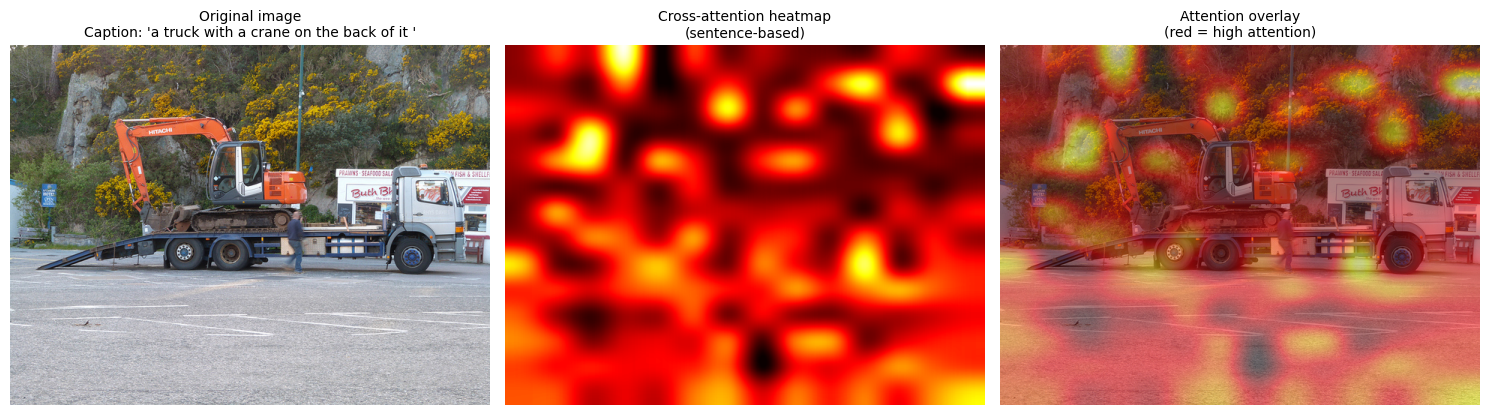


Generated caption:
  - a truck with a crane on the back of it 
Image index: 6016, image_id: 190845

Ground-truth captions:
  - A large transport truck with an orange tractor on back of it.
  - An orange backhoe atop the bed of a white truck.
  - a man loading a bulldozer onto a car hauler 
  - A large truck parked in a stationary position.
  - A tow truck carrying a bulldozer on a trailer.


In [31]:
img, gt_caps = get_image(idx)

caption, cross_attentions, _ = generate_caption_and_attention(img)
attention_heatmap = aggregate_cross_attention(cross_attentions, img.size)

show_image_and_attention(img, caption, attention_heatmap)

print(f"\nGenerated caption:")
print(f"  - {caption}")

print(f"Image index: {idx}, image_id: {img_ids[idx]}")
print("\nGround-truth captions:")
for cap in gt_caps:
    print(f"  - {cap}")

Applying the functions to our example image demonstrates the workings of the insight of our VIT-GPT2 model. Generating the caption and cross attention shows: 
-   **pixel values**: we are passing one image, with 3 color channels (RGB) and 224x224 (image size) as spatial resolution after preprocessing
-   **encoder hidden states**: internal vector representations produced by ViT (encoder) after processing image; batch size 1, with 197 patch embeddings (1 CLS token and 16x16 patches) and each patch converted into 768-dimensional embedding vector --> each image is represented as a sequence of 197 vectors in ℝ⁷⁶⁸; this is later used as Key and Value for cross-attention
-   **generated_ids**: batch size 1 and 13 as caption length in tokens, this is the sequence the decoder produced for the image
-   **cross_attentions**: 12 attention heads in decoder (multi-head attention), 13 number of decoder tokens (one attention distribution per generated token), 197 as number of encoder tokens (attention over all image tokens)

    For each generated caption token (13), and for each attention head(12), you have a probability distribution over all 197 image tokens, telling you which parts of the imaage the token is attending to. 

## Attack Pipeline

- Differential evolution (Storn & Price, 1997) population based optimization algorithm for solving complex multi-modal optimization problems
- needed because blackbox attack, we don't know architecture/gradients of the victim model so gradient based attack doesn't work
- Li et al. use differential evolution as an optimization algorithm to adjust adversarial perturbations so that alterations are imperceptible and highly effective

In [17]:
#Bleu Metrics: calculating bleu scores between reference and predicted captions
def compute_all_bleu_scores(reference_captions, predicted_caption):
    """Fucntion to compute BLEU-1, BLEU-2, and BLEU-4 scores."""
    references = [ref.split() for ref in reference_captions]
    prediction = predicted_caption.split()
    smoothing = SmoothingFunction().method4
    bleu1 = sentence_bleu(references, prediction, weights=(1, 0, 0, 0), smoothing_function=smoothing) #unigram (basic word overlap)
    bleu2 = sentence_bleu(references, prediction, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing) #bigram (2-word sequence overlap)
    bleu4 = sentence_bleu(references, prediction, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing) #4-gram (4-word sequence overlap)
    return bleu1, bleu2, bleu4

In [18]:
# Perturbed Image preparation: converting [C, H, W] array in range [0, 255]
def prepare_image_fixed_size(img_pil, size=224):
    """Resize Image to a fixed size."""
    img_resized = img_pil.resize((size, size), Image.BICUBIC)
    img_array = torch.tensor(np.array(img_resized)).permute(2, 0, 1).float()
    return img_array, img_resized

Function aggregates attentions across heads and tokens to get cross-attention for whole caption. Difference to previous attention calculation: enforcing target size of 224x224 so attention aligns with **perturbed image tensor** later.

In [33]:
# Attention selection but for fixed size 224x224 images; output always shape (224,224)
def aggregate_cross_attention_fixed_size(cross_attentions, target_size=224, patch_size=14):
    """Aggregate attention to fixed size heatmap."""
    last_layer = cross_attentions[-1].squeeze(0)#drop batch dimension
    avg_over_heads = last_layer.mean(dim=0) #average over heads
    avg_over_tokens = avg_over_heads.mean(dim=0) #average over tokens
    patch_attention = avg_over_tokens[1:] #remove CLS
    attention_map = patch_attention.reshape(patch_size, patch_size).cpu().numpy() #reshape to patch grid
    attention_map -= attention_map.min() #normalizing attention map
    denom = attention_map.max() if attention_map.max() > 0 else 1e-8
    attention_map /= denom
    attn_img = Image.fromarray((attention_map * 255).astype(np.uint8))  
    attn_resized = attn_img.resize((target_size, target_size), resample=Image.BICUBIC) #INTERPOLATION: upsampling to 224x224 because evolutionary perutrbations need pixel grid, not 14x14 patches
    return np.array(attn_resized) / 255.0

In [34]:
#Printing example of attention map - for intuition
attn_map = aggregate_cross_attention_fixed_size(cross_attentions, target_size=224, patch_size=14)
print("\nGenerated caption:")
print("  ", caption)
print("\nAttention map info:")
print("  type:", type(attn_map))
print("  shape:", attn_map.shape)   
print("  min:", attn_map.min())
print("  max:", attn_map.max())

# Print a small patch of the attention map for intuition
h_center, w_center = attn_map.shape[0] // 2, attn_map.shape[1] // 2
print("\nCenter 5x5 block of attention map:")
print(attn_map[h_center-2:h_center+3, w_center-2:w_center+3])


Generated caption:
   a truck with a crane on the back of it 

Attention map info:
  type: <class 'numpy.ndarray'>
  shape: (224, 224)
  min: 0.0
  max: 1.0

Center 5x5 block of attention map:
[[0.2627451  0.26666667 0.2745098  0.27843137 0.28627451]
 [0.25882353 0.2627451  0.2745098  0.27843137 0.28627451]
 [0.25490196 0.2627451  0.27058824 0.27843137 0.29019608]
 [0.25098039 0.25882353 0.27058824 0.28235294 0.29411765]
 [0.24705882 0.25490196 0.27058824 0.28235294 0.29803922]]


Function below to choose top 50% of most important pixels based on attention map (output is candidate region, i.e. 25k pixels). Output is list of image coordinates sorted by decreasing attention.


In [39]:
def select_candidate_region(attention_heatmap, percentage=0.5):
    """Select top percentage of pixels based on attention heatmap. Output: candidate region"""
    H, W = attention_heatmap.shape
    flat_attention = attention_heatmap.flatten()
    sorted_indices = np.argsort(flat_attention)[::-1] #sorting by attention descending
    k = int(len(flat_attention) * percentage)
    top_indices = sorted_indices[:k]
    candidate_pixels = []
    for idx in top_indices:
        y = idx // W
        x = idx % W
        candidate_pixels.append((y, x))

    return candidate_pixels

Function below is used in Differential Evolution to select the actual pixels from candidate pixels to perturb the image. We define two potential methods to select these pixels: 
-   topk: deterministic and simply returns the absolute top num_pixels (i.e. top 100 attention pixels)
-   weighted: each candidate pixel is selected with probability proportional to its attention value; bringing diversity into attack initialization

In [38]:
def select_attack_pixels(candidate_pixels, attention_heatmap, num_pixels, method='topk'):
    """Selecting Attack Pixels from candidate region based on method."""
    if method == 'topk':
        return candidate_pixels[:num_pixels]
    elif method == 'weighted':
        weights = np.array([attention_heatmap[y, x] for y, x in candidate_pixels])
        weights = weights / weights.sum()
        indices = np.random.choice(len(candidate_pixels), size=num_pixels, replace=True, p=weights)
        return [candidate_pixels[i] for i in indices]
    else:
        raise ValueError(f"Unknown method: {method}")

In [37]:
# Perturbation: turning DE candidate vector into acutal adversarial image
def apply_perturbation(img_array, perturbations, pixel_coords):
    """
    Applying RGB deltas to selected pixels in the image.
    img_array: [3, H, W] in range [0, 255]
    perturbations: [num_pixels, 3] Deltas
    """
    perturbed = img_array.clone()
    
    for i, (y, x) in enumerate(pixel_coords):
        for c in range(3):
            #Add perturbation and clamp values to valid range [0, 255]
            new_val = perturbed[c, y, x] + perturbations[i, c]
            perturbed[c, y, x] = torch.clamp(new_val, 0, 255)
    
    return perturbed

Function below is used to receive caption. Because input is img_array of perturbed image, the normalization is handled manually here and batch dimension is added to fit what ViT expects.

In [36]:
# Caption generation
@torch.no_grad()
def generate_caption_manual_norm(img_array, model, device, max_length=16):
    """
    Generate caption with manual normalization of img_array (to make sure perturbations do not get lost)
    img_array: [3, H, W] in range [0, 255]
    """
    #Convert img_array to normalized pixel_values (ViT expects this)
    img_normalized = img_array / 255.0
    
    #Standard ViT normalization
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1).to(device)
    std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1).to(device)
    
    img_normalized = img_normalized.to(device)
    img_normalized = (img_normalized - mean) / std
    
    #Add batch dimension
    pixel_values = img_normalized.unsqueeze(0)  # [1, 3, H, W]
    
    #Generate caption
    generated_ids = model.generate(pixel_values, max_length=max_length, num_beams=1)
    caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    
    return caption

Performing Differential Evolution (DE) search over pixel perturbations to find optimal adversarial image based on BLEU-4 minimzation and keeping perturbations small.

In [41]:
# Differential evolution
def differential_evolution_attack_extended(
    img_pil_original,
    pixel_coords, #pixel coordinates selected by attention
    gt_captions, #ground truth captions
    model, #ViT-GPT2 model
    device,
    img_size=224,
    pop_size=20,
    max_iter=5,
    F=0.5,
    delta_range=50, #bounding perturbation values (to make sure perutrbations are  not too large)
    verbose=True
):
    """
    Differential Evolution Attack with BLEU-1, BLEU-2, BLEU-4 Tracking.
    """
    num_pixels = len(pixel_coords)
    
    #Resize to fixed size
    if verbose:
        print(f"\nResizing image from {img_pil_original.size} to {img_size}×{img_size}")
    img_array, img_pil_resized = prepare_image_fixed_size(img_pil_original, size=img_size)
    
    #Original BLEU Scores
    original_caption = generate_caption_manual_norm(img_array, model, device)
    orig_bleu1, orig_bleu2, orig_bleu4 = compute_all_bleu_scores(gt_captions, original_caption)
    
    if verbose:
        print(f"\nOriginal Caption: {original_caption}")
        print(f"Original BLEU-1: {orig_bleu1:.4f}, BLEU-2: {orig_bleu2:.4f}, BLEU-4: {orig_bleu4:.4f}")
    
    #Initialize Population
    # each individual: [num_pixels, 3] array of RGB deltas; random intialization within [-delta_range, delta_range]
    population = []
    for _ in range(pop_size):
        deltas = np.random.randint(-delta_range, delta_range+1, size=(num_pixels, 3))
        population.append(deltas)
    
    #Evaluate initial population based on fitness (BLEU-4 score)
    population_fitness = []
    for individual in population:
        perturbed = apply_perturbation(img_array, individual, pixel_coords)
        caption = generate_caption_manual_norm(perturbed, model, device)
        _, _, bleu4 = compute_all_bleu_scores(gt_captions, caption)
        population_fitness.append(bleu4)
    
    # Track best
    best_idx = np.argmin(population_fitness)
    best_individual = population[best_idx].copy()
    best_bleu4 = population_fitness[best_idx]
    best_caption = generate_caption_manual_norm(
        apply_perturbation(img_array, best_individual, pixel_coords),
        model, device
    )
    best_bleu1, best_bleu2, _ = compute_all_bleu_scores(gt_captions, best_caption)
    
    if verbose:
        print(f"\nGeneration 0:")
        print(f"  Best BLEU-4: {best_bleu4:.4f}, Drop: {orig_bleu4 - best_bleu4:.4f}")
        print(f"  Caption: {best_caption}")
    
    #Differential Evolution Loop: each generation performing mutation, crossover, selection
    for gen in range(1, max_iter + 1):
        new_population = []
        new_fitness = []
        
        for i in range(pop_size):
            candidates = [idx for idx in range(pop_size) if idx != i]
            r1, r2, r3 = np.random.choice(candidates, size=3, replace=False)
            
            mutant = population[r1] + F * (population[r2] - population[r3])
            mutant = np.clip(mutant, -delta_range, delta_range).astype(np.int32)
            
            perturbed = apply_perturbation(img_array, mutant, pixel_coords)
            caption = generate_caption_manual_norm(perturbed, model, device)
            _, _, mutant_bleu4 = compute_all_bleu_scores(gt_captions, caption)
            
            if mutant_bleu4 < population_fitness[i]:
                if mutant_bleu4 < best_bleu4:
                    new_population.append(mutant)
                    new_fitness.append(mutant_bleu4)
                    best_individual = mutant.copy()
                    best_bleu4 = mutant_bleu4
                    best_caption = caption
                    best_bleu1, best_bleu2, _ = compute_all_bleu_scores(gt_captions, caption)
                else:
                    new_population.append(mutant)
                    new_fitness.append(mutant_bleu4)
            else:
                new_population.append(population[i])
                new_fitness.append(population_fitness[i])
        
        population = new_population
        population_fitness = new_fitness
        
        if verbose:
            print(f"\nGeneration {gen}:")
            print(f"  Best BLEU-4: {best_bleu4:.4f}, Drop: {orig_bleu4 - best_bleu4:.4f}")
            print(f"  Caption: {best_caption}")
    
    # 6. Create best perturbed image
    best_perturbed_array = apply_perturbation(img_array, best_individual, pixel_coords)
    best_perturbed_img = Image.fromarray(
        best_perturbed_array.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
    )
    
    # Return all metrics
    results = {
        'adv_image': best_perturbed_img,
        'orig_caption': original_caption,
        'adv_caption': best_caption,
        'orig_bleu1': orig_bleu1,
        'orig_bleu2': orig_bleu2,
        'orig_bleu4': orig_bleu4,
        'adv_bleu1': best_bleu1,
        'adv_bleu2': best_bleu2,
        'adv_bleu4': best_bleu4,
        'bleu1_drop': orig_bleu1 - best_bleu1,
        'bleu2_drop': orig_bleu2 - best_bleu2,
        'bleu4_drop': orig_bleu4 - best_bleu4
    }
    
    return results

In [45]:
# Batch Attack
def run_batch_attack(
    num_images=1000,
    start_idx=0,
    attention_percentage=0.5,
    num_attack_pixels=500,
    pixel_selection='topk',
    img_size=224,
    pop_size=20,
    max_iter=5,
    F=0.5,
    delta_range=50
):
    """Führe Attack auf num_images Bildern durch."""
    print("="*80)
    print(f"Running Batch Attack on {num_images} images")
    print("="*80)
    
    results_list = []
    
    for i in range(num_images):
        img_idx = start_idx + i
        
        if img_idx >= len(img_ids):
            print(f"\nReached end of dataset at index {img_idx}")
            break
        
        print(f"\n{'='*80}")
        print(f"Processing image {i+1}/{num_images} (index {img_idx})")
        print(f"{'='*80}")
        
        try:
            # 1. Load image
            img_original, gt_captions = get_image(img_idx)
            print(f"Image ID: {img_ids[img_idx]}")
            
            # 2. Resize
            _, img_resized = prepare_image_fixed_size(img_original, size=img_size)
            
            # 3. Attention
            print("[1/4] Generating attention...")
            _, cross_attentions, _ = generate_caption_and_attention(img_resized)
            attention_heatmap = aggregate_cross_attention_fixed_size(
                cross_attentions, target_size=img_size
            )
            
            # 4. Candidate Region
            print(f"[2/4] Selecting candidate region (top {attention_percentage*100:.0f}%)...")
            candidate_pixels = select_candidate_region(attention_heatmap, percentage=attention_percentage)
            
            # 5. Attack Pixels
            print(f"[3/4] Selecting {num_attack_pixels} attack pixels...")
            attack_pixels = select_attack_pixels(
                candidate_pixels, attention_heatmap, num_attack_pixels, method=pixel_selection
            )
            
            # 6. Attack
            print(f"[4/4] Running DE attack...")
            attack_results = differential_evolution_attack_extended(
                img_pil_original=img_resized,
                pixel_coords=attack_pixels,
                gt_captions=gt_captions,
                model=model,
                device=device,
                img_size=img_size,
                pop_size=pop_size,
                max_iter=max_iter,
                F=F,
                delta_range=delta_range,
                verbose=True
            )
            
            # Store results
            attack_results['img_idx'] = img_idx
            attack_results['img_id'] = img_ids[img_idx]
            attack_results['gt_captions'] = gt_captions
            attack_results['img_resized'] = img_resized
            attack_results['attention_heatmap'] = attention_heatmap
            attack_results['attack_pixels'] = attack_pixels
            
            results_list.append(attack_results)
            
            print(f"\n✓ Image {i+1} completed:")
            print(f"  BLEU-1 Drop: {attack_results['bleu1_drop']:.4f}")
            print(f"  BLEU-2 Drop: {attack_results['bleu2_drop']:.4f}")
            print(f"  BLEU-4 Drop: {attack_results['bleu4_drop']:.4f}")
            
        except Exception as e:
            print(f"\n✗ Error processing image {img_idx}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print("\n" + "="*80)
    print(f"BATCH ATTACK COMPLETED! Processed {len(results_list)} images")
    print("="*80)
    
    return results_list

In [44]:
# Visualization and results
def visualize_top3_attacks(results_list, metric='bleu4_drop'):
    """Visualisiere die 3 besten Angriffe inkl. Original- und Adversarial-Captions."""
    # Sort by chosen metric (e.g. 'bleu4_drop') descending
    sorted_results = sorted(results_list, key=lambda x: x[metric], reverse=True)
    top3 = sorted_results[:3]
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    
    for i, result in enumerate(top3):
        # --- 1) Original image ---
        axes[i, 0].imshow(result['img_resized'])
        axes[i, 0].set_title(
            f"#{i+1} Original (ID: {result['img_id']})",
            fontsize=10
        )
        axes[i, 0].axis("off")
        
        # --- 2) Adversarial image ---
        axes[i, 1].imshow(result['adv_image'])
        axes[i, 1].set_title("Adversarial", fontsize=10)
        axes[i, 1].axis("off")
        
        # --- 3) Text panel: captions + stats ---
        orig_cap_full = result['orig_caption']
        adv_cap_full = result['adv_caption']
        
        stats_text = (
            f"Original caption:\n"
            f"  {orig_cap_full}\n\n"
            f"Adversarial caption:\n"
            f"  {adv_cap_full}\n\n"
            f"BLEU-1 Drop: {result['bleu1_drop']:.4f}\n"
            f"BLEU-2 Drop: {result['bleu2_drop']:.4f}\n"
            f"BLEU-4 Drop: {result['bleu4_drop']:.4f}\n\n"
            f"Original BLEU-4: {result['orig_bleu4']:.4f}\n"
            f"Adversarial BLEU-4: {result['adv_bleu4']:.4f}\n\n"
            f"Attack pixels: {len(result['attack_pixels'])}"
        )
        
        axes[i, 2].text(
            0.0, 0.5, stats_text,
            fontsize=11,
            va='center',
            ha='left',
            wrap=True,
        )
        axes[i, 2].set_xlim(0, 1)
        axes[i, 2].set_ylim(0, 1)
        axes[i, 2].axis("off")
    
    plt.suptitle(f"Top 3 Attacks by {metric.upper()}", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()


def create_results_table(results_list):
    """Erstelle Ergebnis-Tabelle wie im Paper."""
    import pandas as pd
    
    avg_bleu1_drop = np.mean([r['bleu1_drop'] for r in results_list])
    avg_bleu2_drop = np.mean([r['bleu2_drop'] for r in results_list])
    avg_bleu4_drop = np.mean([r['bleu4_drop'] for r in results_list])
    
    avg_orig_bleu1 = np.mean([r['orig_bleu1'] for r in results_list])
    avg_orig_bleu2 = np.mean([r['orig_bleu2'] for r in results_list])
    avg_orig_bleu4 = np.mean([r['orig_bleu4'] for r in results_list])
    
    avg_adv_bleu1 = np.mean([r['adv_bleu1'] for r in results_list])
    avg_adv_bleu2 = np.mean([r['adv_bleu2'] for r in results_list])
    avg_adv_bleu4 = np.mean([r['adv_bleu4'] for r in results_list])
    
    std_bleu1_drop = np.std([r['bleu1_drop'] for r in results_list])
    std_bleu2_drop = np.std([r['bleu2_drop'] for r in results_list])
    std_bleu4_drop = np.std([r['bleu4_drop'] for r in results_list])
    
    success_rate = len([r for r in results_list if r['bleu4_drop'] > 0]) / len(results_list) * 100
    
    data = {
        'Metric': ['BLEU-1', 'BLEU-2', 'BLEU-4'],
        'Original Score': [f"{avg_orig_bleu1:.4f}", f"{avg_orig_bleu2:.4f}", f"{avg_orig_bleu4:.4f}"],
        'Adversarial Score': [f"{avg_adv_bleu1:.4f}", f"{avg_adv_bleu2:.4f}", f"{avg_adv_bleu4:.4f}"],
        'Average Drop': [f"{avg_bleu1_drop:.4f}", f"{avg_bleu2_drop:.4f}", f"{avg_bleu4_drop:.4f}"],
        'Std Dev': [f"{std_bleu1_drop:.4f}", f"{std_bleu2_drop:.4f}", f"{std_bleu4_drop:.4f}"]
    }
    
    df = pd.DataFrame(data)
    
    print("\n" + "="*80)
    print("ATTACK RESULTS TABLE")
    print("="*80)
    print(f"\nDataset: Mini-COCO")
    print(f"Model: ViT-GPT2")
    print(f"Number of Images: {len(results_list)}")
    print(f"Attack Success Rate: {success_rate:.2f}%")
    print(f"Attack Pixels: {len(results_list[0]['attack_pixels'])}")
    print(f"Population Size: 20, Iterations: 5, Delta Range: ±50")
    print("\n" + "-"*80)
    print(df.to_string(index=False))
    print("-"*80)
    print(f"\nBest BLEU-4 Drop: {max([r['bleu4_drop'] for r in results_list]):.4f}")
    print(f"Worst BLEU-4 Drop: {min([r['bleu4_drop'] for r in results_list]):.4f}")
    print(f"Median BLEU-4 Drop: {np.median([r['bleu4_drop'] for r in results_list]):.4f}")
    print("="*80 + "\n")
    
    return df

def plot_bleu_drop_distribution(results_list):
    """Plotte BLEU Drop Verteilungen."""
    bleu1_drops = [r['bleu1_drop'] for r in results_list]
    bleu2_drops = [r['bleu2_drop'] for r in results_list]
    bleu4_drops = [r['bleu4_drop'] for r in results_list]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].hist(bleu1_drops, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(np.mean(bleu1_drops), color='red', linestyle='--', linewidth=2, 
                    label=f'Mean: {np.mean(bleu1_drops):.4f}')
    axes[0].set_xlabel('BLEU-1 Drop')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('BLEU-1 Drop Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(bleu2_drops, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(bleu2_drops), color='red', linestyle='--', linewidth=2, 
                    label=f'Mean: {np.mean(bleu2_drops):.4f}')
    axes[1].set_xlabel('BLEU-2 Drop')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('BLEU-2 Drop Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].hist(bleu4_drops, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[2].axvline(np.mean(bleu4_drops), color='red', linestyle='--', linewidth=2, 
                    label=f'Mean: {np.mean(bleu4_drops):.4f}')
    axes[2].set_xlabel('BLEU-4 Drop')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('BLEU-4 Drop Distribution')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Running Batch Attack on 30 images

Processing image 1/30 (index 0)
Image ID: 9
[1/4] Generating attention...
pixel_values.shape: torch.Size([1, 3, 224, 224])
encoder_hidden_states.shape: torch.Size([1, 197, 768])
generated_ids.shape: torch.Size([1, 12])
cross_attentions[-1].shape: torch.Size([1, 12, 12, 197])
[2/4] Selecting candidate region (top 50%)...
[3/4] Selecting 1000 attack pixels...
[4/4] Running DE attack...

Resizing image from (224, 224) to 224×224

Original Caption: a lunch box filled with different types of food 
Original BLEU-1: 0.5556, BLEU-2: 0.4564, BLEU-4: 0.1817

Generation 0:
  Best BLEU-4: 0.1817, Drop: 0.0000
  Caption: a lunch box filled with different types of food 

Generation 1:
  Best BLEU-4: 0.1817, Drop: 0.0000
  Caption: a lunch box filled with different types of food 

Generation 2:
  Best BLEU-4: 0.1817, Drop: 0.0000
  Caption: a lunch box filled with different types of food 

Generation 3:
  Best BLEU-4: 0.1817, Drop: 0.0000
  Caption: a lunch box fill

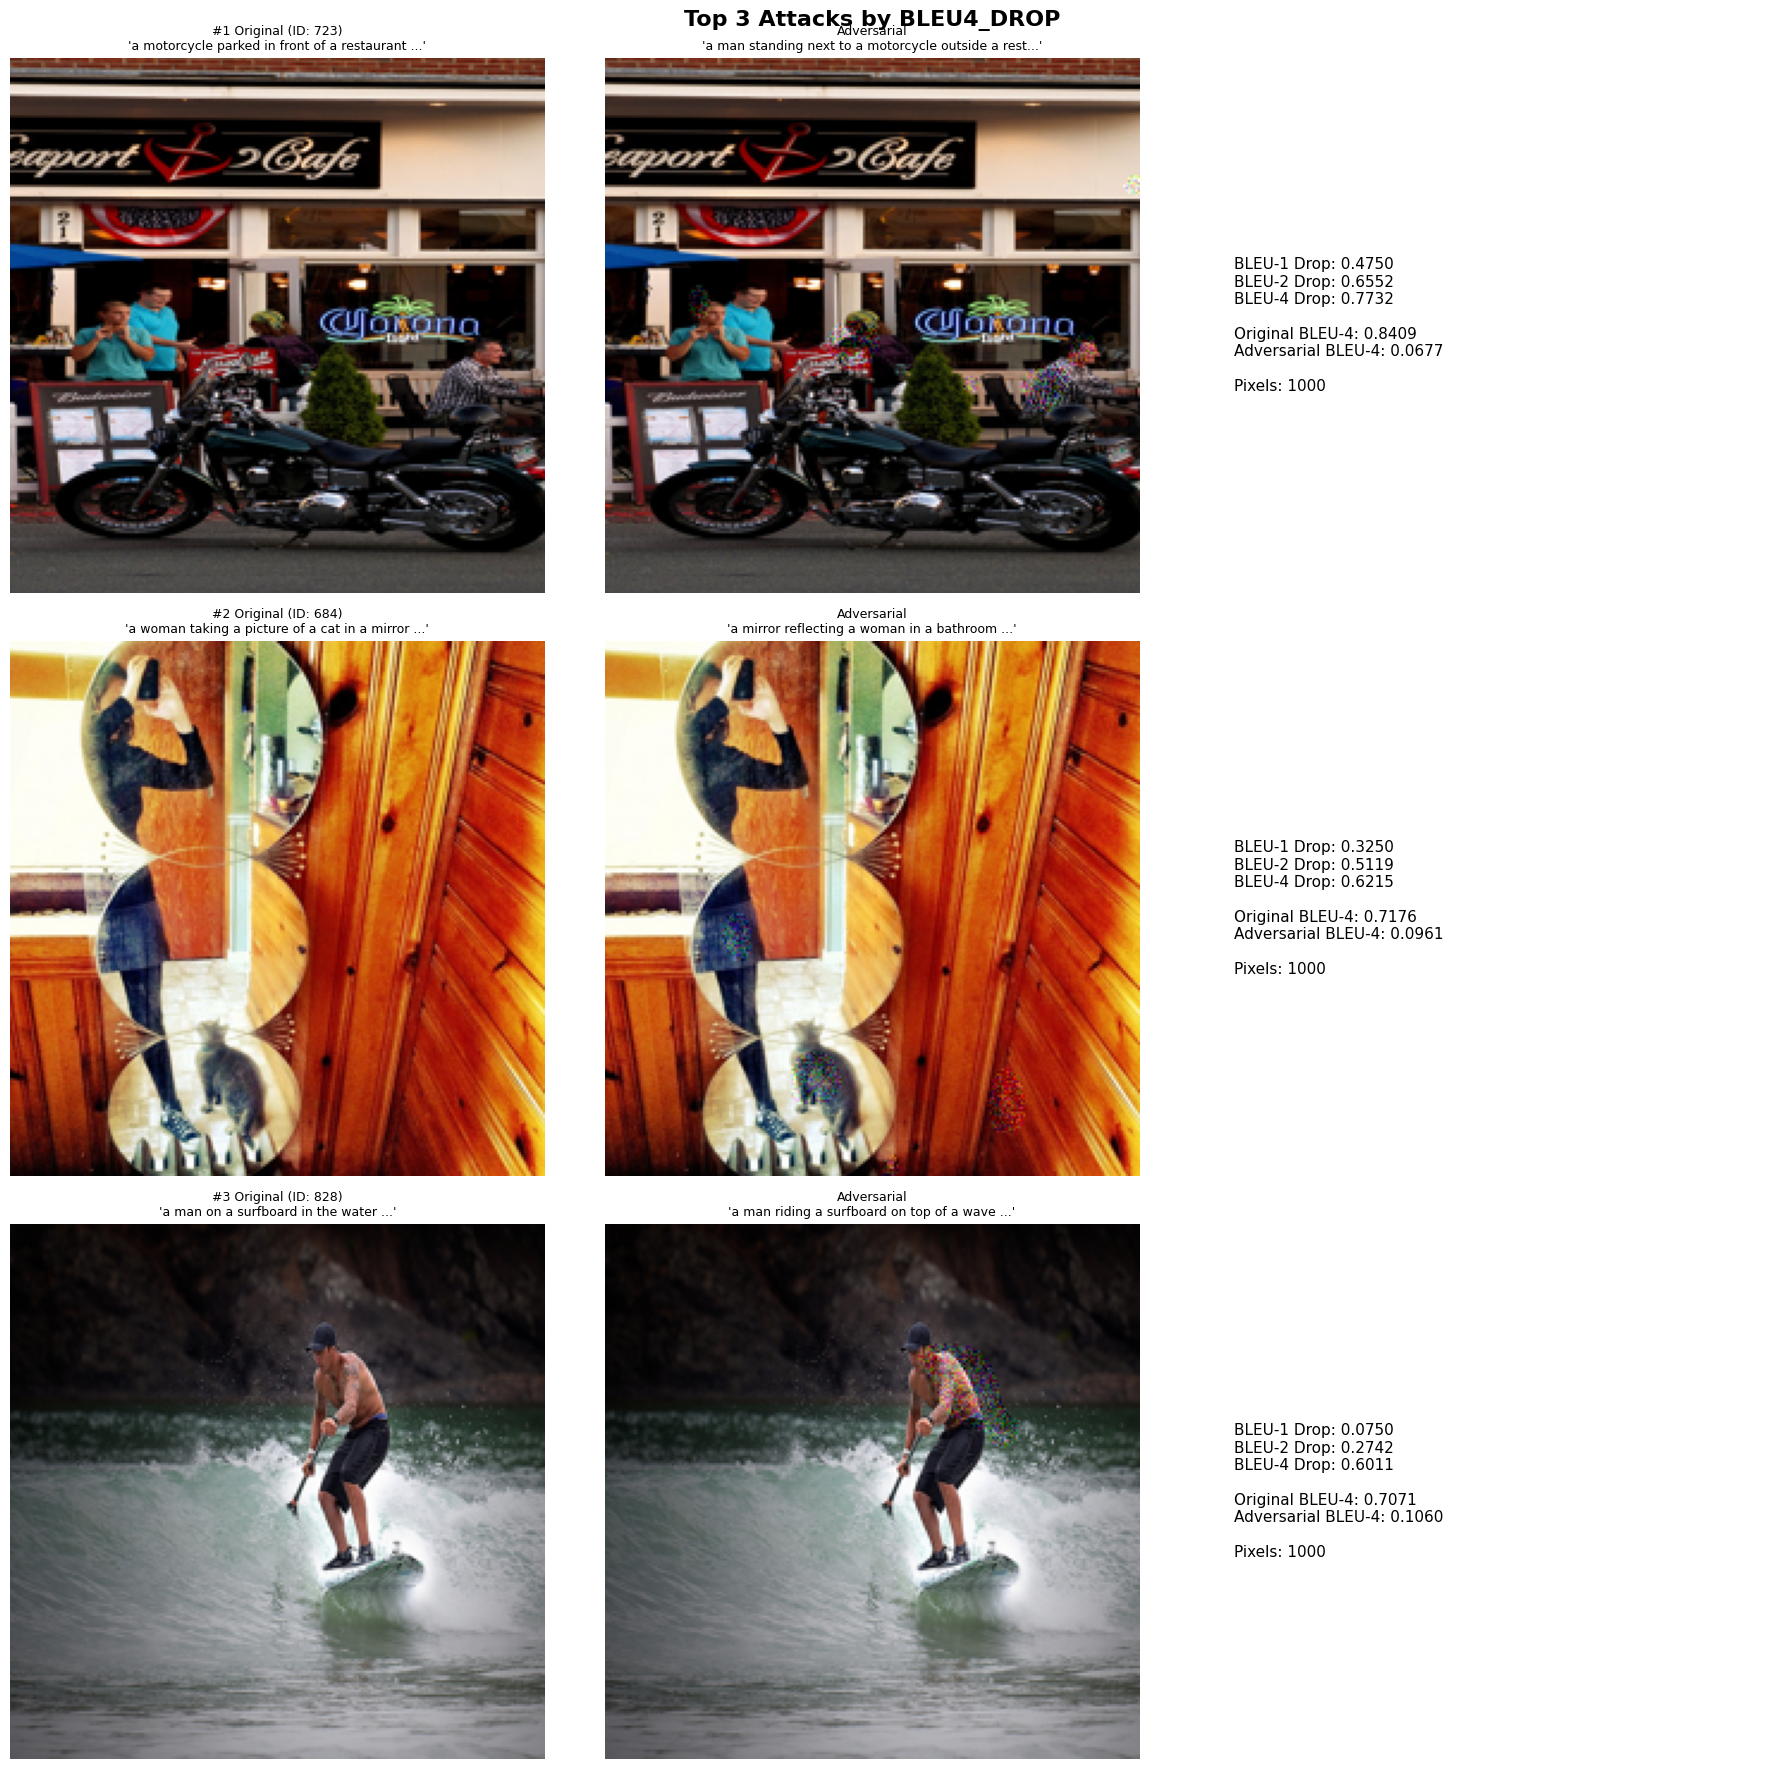

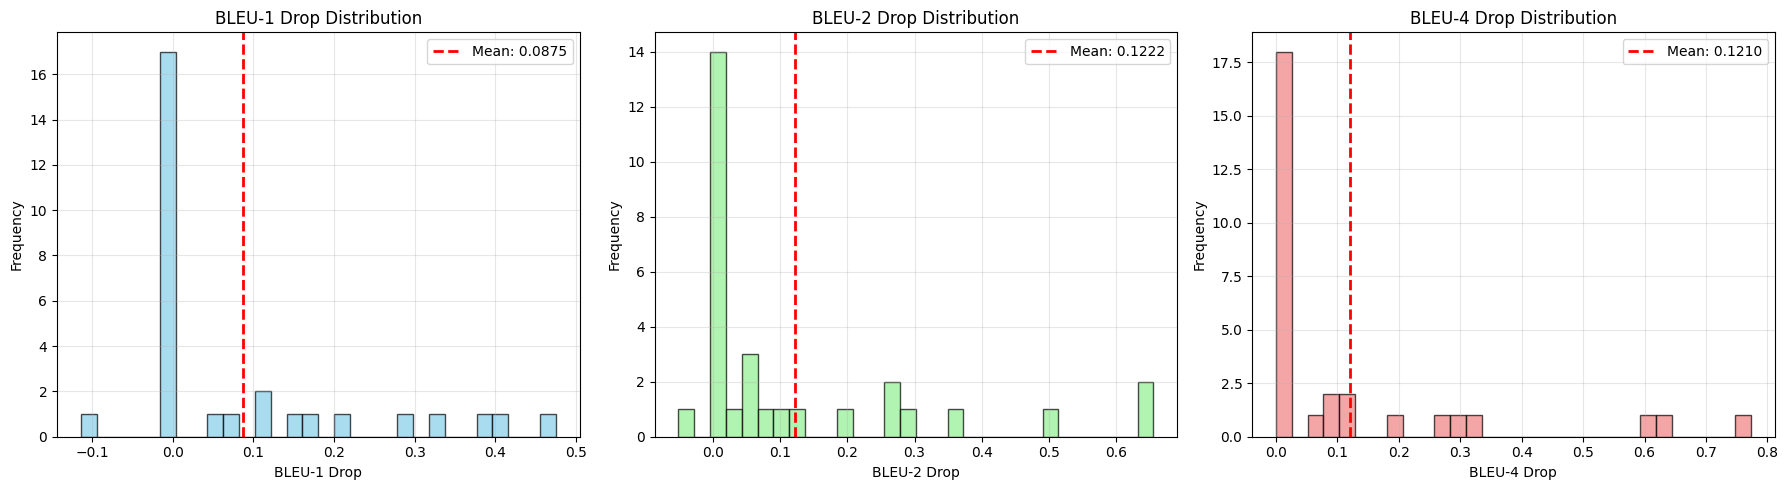

In [43]:
# Execute batch attack
results = run_batch_attack(
    num_images=30,
    start_idx=0,
    attention_percentage=0.5,
    num_attack_pixels=1000,
    pixel_selection='topk',
    img_size=224,
    pop_size=20,
    max_iter=5,
    F=0.5,
    delta_range=50
)

# Evaluation
df = create_results_table(results)
visualize_top3_attacks(results, metric='bleu4_drop')
plot_bleu_drop_distribution(results)

# Save
import pickle
with open('attack_results.pkl', 'wb') as f:
    pickle.dump(results, f)